In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
import optuna
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import fbeta_score

pd.options.display.float_format = "{:.5f}".format

## inladen data

In [14]:
deciduous_teeth = pd.read_csv("../data/deciduous_teeth.csv", sep=";")

## inladen p(age|dentition)

In [15]:
lls_ll_stage1 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_ll_dec_stage1.csv", sep=";"
)
lls_xgb_stage1 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_xgb_dec_stage1.csv", sep=";"
)
lls_cb_stage1 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_cb_dec_stage1.csv", sep=";"
)

In [16]:
lls_ll_stage2 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_ll_dec_stage2.csv", sep=";"
)
lls_xgb_stage2 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_xgb_dec_stage2.csv", sep=";"
)
lls_cb_stage2 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_cb_dec_stage2.csv", sep=";"
)

## clf

In [ ]:
st_df = pd.read_csv("age_probs/st_df_dec.csv", sep=";")

In [18]:
def objective_tree(trial, X, y, groups, max_max_depth):

    clf_choice = trial.suggest_categorical("clf_choice", ["ExtraTreesClassifier"])
    # Search space
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 1000),
        "max_depth": trial.suggest_int("max_depth", 2, max_max_depth),
    }

    inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in inner_cv.split(X, y, groups):

        X_tr, y_tr = X[train_idx], y.iloc[train_idx]
        X_val, y_val = X[val_idx], y.iloc[val_idx]

        clf = eval(clf_choice)(
            **params, random_state=42, class_weight="balanced_subsample"
        )

        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)

        score = fbeta_score(y_val, preds, beta=2.25, pos_label=0)
        scores.append(score)

    return np.mean(scores)

In [ ]:
N_OUTER_FOLDS = 5
N_INNER_FOLDS = 3
clf_preds_perma = []
cv_truths_perma = []
cv_dogs_perma = []

lodo = GroupKFold(N_OUTER_FOLDS, shuffle=True, random_state=42)
for i, (train_index, test_index) in enumerate(
    lodo.split(X=deciduous_teeth, groups=deciduous_teeth["DOG"])
):
    print(i)

    train_outer = deciduous_teeth.iloc[train_index]
    test_outer = deciduous_teeth.iloc[test_index]

    # dogs uithalen zodat we lls kunnen splitsen
    train_outer_dogs = train_outer["DOG"].unique()
    test_outer_dogs = test_outer["DOG"].unique()

    X_train_ll1 = (
        lls_ll_stage1[lls_ll_stage1["dog"].isin(train_outer_dogs)]
        .groupby(["dog", "checkup"])["ll"]
        .agg(list)
    )
    X_train_ll2 = (
        lls_ll_stage2[lls_ll_stage2["dog"].isin(train_outer_dogs)]
        .groupby(["dog", "checkup"])["ll"]
        .agg(list)
    )
    X_train_xgb1 = (
        lls_xgb_stage1[lls_xgb_stage1["dog"].isin(train_outer_dogs)]
        .groupby(["dog", "checkup"])["ll"]
        .agg(list)
    )
    X_train_xgb2 = (
        lls_xgb_stage2[lls_xgb_stage2["dog"].isin(train_outer_dogs)]
        .groupby(["dog", "checkup"])["ll"]
        .agg(list)
    )
    X_train_cb1 = (
        lls_cb_stage1[lls_cb_stage1["dog"].isin(train_outer_dogs)]
        .groupby(["dog", "checkup"])["ll"]
        .agg(list)
    )
    X_train_cb2 = (
        lls_cb_stage2[lls_cb_stage2["dog"].isin(train_outer_dogs)]
        .groupby(["dog", "checkup"])["ll"]
        .agg(list)
    )
    X_train_st_ll = (
        st_df[st_df["DOG"].isin(train_outer_dogs)]
        .groupby(["DOG", "check_up_time"])["LL"]
        .agg(list)
    )
    X_train_st_xgb = (
        st_df[st_df["DOG"].isin(train_outer_dogs)]
        .groupby(["DOG", "check_up_time"])["XGB"]
        .agg(list)
    )
    X_train_st_cb = (
        st_df[st_df["DOG"].isin(train_outer_dogs)]
        .groupby(["DOG", "check_up_time"])["CB"]
        .agg(list)
    )
    y_train = (
        lls_ll_stage1[lls_ll_stage1["dog"].isin(train_outer_dogs)]
        .groupby(["dog", "checkup"])["ground_truth"]
        .min()
    )

    X_test_ll1 = (
        lls_ll_stage1[lls_ll_stage1["dog"].isin(test_outer_dogs)]
        .groupby(["dog", "checkup"])["ll"]
        .agg(list)
    )
    X_test_ll2 = (
        lls_ll_stage2[lls_ll_stage2["dog"].isin(test_outer_dogs)]
        .groupby(["dog", "checkup"])["ll"]
        .agg(list)
    )
    X_test_xgb1 = (
        lls_xgb_stage1[lls_xgb_stage1["dog"].isin(test_outer_dogs)]
        .groupby(["dog", "checkup"])["ll"]
        .agg(list)
    )
    X_test_xgb2 = (
        lls_xgb_stage2[lls_xgb_stage2["dog"].isin(test_outer_dogs)]
        .groupby(["dog", "checkup"])["ll"]
        .agg(list)
    )
    X_test_cb1 = (
        lls_cb_stage1[lls_cb_stage1["dog"].isin(test_outer_dogs)]
        .groupby(["dog", "checkup"])["ll"]
        .agg(list)
    )
    X_test_cb2 = (
        lls_cb_stage2[lls_cb_stage2["dog"].isin(test_outer_dogs)]
        .groupby(["dog", "checkup"])["ll"]
        .agg(list)
    )
    X_test_st_ll = (
        st_df[st_df["DOG"].isin(test_outer_dogs)]
        .groupby(["DOG", "check_up_time"])["LL"]
        .agg(list)
    )
    X_test_st_xgb = (
        st_df[st_df["DOG"].isin(test_outer_dogs)]
        .groupby(["DOG", "check_up_time"])["XGB"]
        .agg(list)
    )
    X_test_st_cb = (
        st_df[st_df["DOG"].isin(test_outer_dogs)]
        .groupby(["DOG", "check_up_time"])["CB"]
        .agg(list)
    )
    y_test = (
        lls_ll_stage1[lls_ll_stage1["dog"].isin(test_outer_dogs)]
        .groupby(["dog", "checkup"])["ground_truth"]
        .min()
    )

    # Convert list of ll values into fixed-length feature vectors
    # append likelihoods to log-likelihoods
    X_train_ll_matrix1 = np.array([np.array(x) for x in X_train_ll1])
    X_train_xgb_matrix1 = np.array([np.array(x) for x in X_train_xgb1])
    X_train_cb_matrix1 = np.array([np.array(x) for x in X_train_cb1])
    X_train_ll_matrix2 = np.array([np.array(x) for x in X_train_ll2])
    X_train_xgb_matrix2 = np.array([np.array(x) for x in X_train_xgb2])
    X_train_cb_matrix2 = np.array([np.array(x) for x in X_train_cb2])
    X_train_st_ll_matrix = np.array([np.array(x) for x in X_train_st_ll])
    X_train_st_xgb_matrix = np.array([np.array(x) for x in X_train_st_xgb])
    X_train_st_cb_matrix = np.array([np.array(x) for x in X_train_st_cb])

    X_train_prep = np.hstack(
        [
            X_train_ll_matrix1,
            X_train_xgb_matrix1,
            X_train_cb_matrix1,
            X_train_ll_matrix2,
            X_train_xgb_matrix2,
            X_train_cb_matrix2,
            X_train_st_ll_matrix,
            X_train_st_xgb_matrix,
            X_train_st_cb_matrix,
        ]
    )

    X_test_ll_matrix1 = np.array([np.array(x) for x in X_test_ll1])
    X_test_xgb_matrix1 = np.array([np.array(x) for x in X_test_xgb1])
    X_test_cb_matrix1 = np.array([np.array(x) for x in X_test_cb1])
    X_test_ll_matrix2 = np.array([np.array(x) for x in X_test_ll2])
    X_test_xgb_matrix2 = np.array([np.array(x) for x in X_test_xgb2])
    X_test_cb_matrix2 = np.array([np.array(x) for x in X_test_cb2])
    X_test_st_ll_matrix = np.array([np.array(x) for x in X_test_st_ll])
    X_test_st_xgb_matrix = np.array([np.array(x) for x in X_test_st_xgb])
    X_test_st_cb_matrix = np.array([np.array(x) for x in X_test_st_cb])
    X_test_prep = np.hstack(
        [
            X_test_ll_matrix1,
            X_test_xgb_matrix1,
            X_test_cb_matrix1,
            X_test_ll_matrix2,
            X_test_xgb_matrix2,
            X_test_cb_matrix2,
            X_test_st_ll_matrix,
            X_test_st_xgb_matrix,
            X_test_st_cb_matrix,
        ]
    )

    # INNER LOOP FOR HYPERPARAM TUNING
    study = optuna.create_study(direction="maximize")
    study.optimize(
        lambda trial: objective_tree(
            trial,
            X_train_prep,
            y_train,
            groups=[idx[0] for idx in X_train_ll1.index],  # dog grouping
            max_max_depth=20,
        ),
        n_trials=10,
    )

    best_params = study.best_params
    print("Best hyperparameters:", best_params)
    clf_outer_choice = best_params.pop("clf_choice")

    clf_outer = ExtraTreesClassifier(
        **best_params, random_state=42, class_weight="balanced_subsample"
    ).fit(X_train_prep, y_train)

    clf_preds_perma.extend(clf_outer.predict(X_test_prep))
    cv_truths_perma.extend(y_test)

0


[I 2026-03-09 11:53:58,762] A new study created in memory with name: no-name-7c43de8a-5b1f-4cae-af88-911f426b1a5a
[I 2026-03-09 11:54:17,466] Trial 0 finished with value: 0.9677848723911997 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 737, 'max_depth': 20}. Best is trial 0 with value: 0.9677848723911997.
[I 2026-03-09 11:54:18,891] Trial 1 finished with value: 0.9641613330335078 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 55, 'max_depth': 15}. Best is trial 0 with value: 0.9677848723911997.
[I 2026-03-09 11:55:04,259] Trial 2 finished with value: 0.9660480641579688 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 707, 'max_depth': 18}. Best is trial 0 with value: 0.9677848723911997.
[I 2026-03-09 11:55:36,800] Trial 3 finished with value: 0.9630175333270894 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 509, 'max_depth': 14}. Best is trial 0 with value: 0.9677848723911997.
[I 2026-03-09 1

Best hyperparameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 737, 'max_depth': 20}
1


[I 2026-03-09 11:57:40,715] A new study created in memory with name: no-name-ce0c033c-0fda-4089-b084-107157d3f9be
[I 2026-03-09 11:58:35,875] Trial 0 finished with value: 0.9675159981576419 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 854, 'max_depth': 16}. Best is trial 0 with value: 0.9675159981576419.
[I 2026-03-09 11:59:23,242] Trial 1 finished with value: 0.9704749376560291 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 664, 'max_depth': 20}. Best is trial 1 with value: 0.9704749376560291.
[I 2026-03-09 11:59:47,108] Trial 2 finished with value: 0.9590696766363579 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 393, 'max_depth': 12}. Best is trial 1 with value: 0.9704749376560291.
[I 2026-03-09 12:00:52,589] Trial 3 finished with value: 0.9706102164692476 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 971, 'max_depth': 20}. Best is trial 3 with value: 0.9706102164692476.
[I 2026-03-09 

Best hyperparameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 971, 'max_depth': 20}
2


...

Best hyperparameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 722, 'max_depth': 20}
3


[I 2026-03-09 12:09:12,096] A new study created in memory with name: no-name-4efe25c4-47b2-4a54-909b-bed0a9a02030
[I 2026-03-09 12:09:14,745] Trial 0 finished with value: 0.8863147874001035 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 103, 'max_depth': 2}. Best is trial 0 with value: 0.8863147874001035.
[I 2026-03-09 12:09:28,364] Trial 1 finished with value: 0.9567109326891668 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 236, 'max_depth': 13}. Best is trial 1 with value: 0.9567109326891668.
[I 2026-03-09 12:09:55,244] Trial 2 finished with value: 0.926909387370119 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 574, 'max_depth': 8}. Best is trial 1 with value: 0.9567109326891668.
[I 2026-03-09 12:10:41,674] Trial 3 finished with value: 0.9643809293840814 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 668, 'max_depth': 20}. Best is trial 3 with value: 0.9643809293840814.
[I 2026-03-09 12:

Best hyperparameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 668, 'max_depth': 20}
4


[I 2026-03-09 12:14:19,215] A new study created in memory with name: no-name-cdeab7f2-5e09-4cde-ad0d-c11166fa80a9
[I 2026-03-09 12:14:51,831] Trial 0 finished with value: 0.9471833186624705 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 616, 'max_depth': 10}. Best is trial 0 with value: 0.9471833186624705.
[I 2026-03-09 12:15:39,017] Trial 1 finished with value: 0.9705953956710026 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 670, 'max_depth': 19}. Best is trial 1 with value: 0.9705953956710026.
[I 2026-03-09 12:16:38,714] Trial 2 finished with value: 0.9693428561085198 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 860, 'max_depth': 18}. Best is trial 1 with value: 0.9705953956710026.
[I 2026-03-09 12:17:22,108] Trial 3 finished with value: 0.9473048520120221 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 809, 'max_depth': 10}. Best is trial 1 with value: 0.9705953956710026.
[I 2026-03-09 

Best hyperparameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 153, 'max_depth': 20}


              precision    recall  f1-score   support

       False       0.95      0.98      0.96      5310
        True       0.73      0.54      0.62       644

    accuracy                           0.93      5954
   macro avg       0.84      0.76      0.79      5954
weighted avg       0.92      0.93      0.92      5954



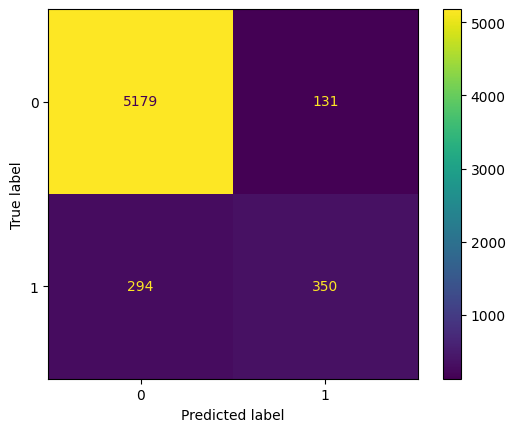

In [45]:
# nested cv
ConfusionMatrixDisplay(
    confusion_matrix(
        cv_truths_perma,
        clf_preds_perma,
    )
).plot()

print(
    classification_report(
        cv_truths_perma,
        clf_preds_perma,
    )
)

# permanent

In [5]:
permanent_teeth = pd.read_csv("../data/permanent_teeth.csv", sep=";")

In [6]:
lls_ll_perma_stage1 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_ll_perma_stage1.csv",
    sep=";",
    index_col=False,
)
lls_ll_perma_stage2 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_ll_perma_stage2.csv",
    sep=";",
    index_col=False,
)
lls_ll_perma_stage3 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_ll_perma_stage3.csv",
    sep=";",
    index_col=False,
)

lls_xgb_perma_stage1 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_xgb_perma_stage1.csv",
    sep=";",
    index_col=False,
)
lls_xgb_perma_stage2 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_xgb_perma_stage2.csv",
    sep=";",
    index_col=False,
)
lls_xgb_perma_stage3 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_xgb_perma_stage3.csv",
    sep=";",
    index_col=False,
)

lls_cb_perma_stage1 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_cb_perma_stage1.csv",
    sep=";",
    index_col=False,
)
lls_cb_perma_stage2 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_cb_perma_stage2.csv",
    sep=";",
    index_col=False,
)
lls_cb_perma_stage3 = pd.read_csv(
    "dental_likelihoods/dental_likelihoods_cb_perma_stage3.csv",
    sep=";",
    index_col=False,
)

st_df_perma = pd.read_csv("age_probs/st_df_perma_CLEAN.csv", sep=";", index_col=False)
st_df_perma.rename(columns={"DOG": "dog", "check_up_time": "checkup"}, inplace=True)

In [7]:
def get_features_per_checkup(df, dogs, select_col):
    return df[df["dog"].isin(dogs)].groupby(["dog", "checkup"])[select_col].agg(list)

In [10]:
N_OUTER_FOLDS = 5
N_INNER_FOLDS = 3
clf_preds_perma = []
cv_truths_perma = []
cv_dogs_perma = []

lodo = StratifiedGroupKFold(N_OUTER_FOLDS, shuffle=True, random_state=42)
for i, (train_index, test_index) in enumerate(
    lodo.split(
        X=permanent_teeth, y=permanent_teeth["CENS"], groups=permanent_teeth["DOG"]
    )
):
    print(i)

    train_outer = permanent_teeth.iloc[train_index]
    test_outer = permanent_teeth.iloc[test_index]

    # dogs uithalen zodat we lls kunnen splitsen
    train_outer_dogs = train_outer["DOG"].unique()
    test_outer_dogs = test_outer["DOG"].unique()

    X_train_ll1 = get_features_per_checkup(lls_ll_perma_stage1, train_outer_dogs, "ll")
    X_train_ll2 = get_features_per_checkup(lls_ll_perma_stage2, train_outer_dogs, "ll")
    X_train_ll3 = get_features_per_checkup(lls_ll_perma_stage3, train_outer_dogs, "ll")
    X_train_st_ll = get_features_per_checkup(st_df_perma, train_outer_dogs, "LL")
    X_train_xgb1 = get_features_per_checkup(
        lls_xgb_perma_stage1, train_outer_dogs, "ll"
    )
    X_train_xgb2 = get_features_per_checkup(
        lls_xgb_perma_stage2, train_outer_dogs, "ll"
    )
    X_train_xgb3 = get_features_per_checkup(
        lls_xgb_perma_stage3, train_outer_dogs, "ll"
    )
    X_train_st_xgb = get_features_per_checkup(st_df_perma, train_outer_dogs, "XGB")
    X_train_cb1 = get_features_per_checkup(lls_cb_perma_stage1, train_outer_dogs, "ll")
    X_train_cb2 = get_features_per_checkup(lls_cb_perma_stage2, train_outer_dogs, "ll")
    X_train_cb3 = get_features_per_checkup(lls_cb_perma_stage3, train_outer_dogs, "ll")
    X_train_st_cb = get_features_per_checkup(st_df_perma, train_outer_dogs, "CB")
    y_train = (
        lls_ll_perma_stage1[lls_ll_perma_stage1["dog"].isin(train_outer_dogs)]
        .groupby(["dog", "checkup"])["ground_truth"]
        .min()
    )

    X_test_ll1 = get_features_per_checkup(lls_ll_perma_stage1, test_outer_dogs, "ll")
    X_test_ll2 = get_features_per_checkup(lls_ll_perma_stage2, test_outer_dogs, "ll")
    X_test_ll3 = get_features_per_checkup(lls_ll_perma_stage3, test_outer_dogs, "ll")
    X_test_st_ll = get_features_per_checkup(st_df_perma, test_outer_dogs, "LL")
    X_test_xgb1 = get_features_per_checkup(lls_xgb_perma_stage1, test_outer_dogs, "ll")
    X_test_xgb2 = get_features_per_checkup(lls_xgb_perma_stage2, test_outer_dogs, "ll")
    X_test_xgb3 = get_features_per_checkup(lls_xgb_perma_stage3, test_outer_dogs, "ll")
    X_test_st_xgb = get_features_per_checkup(st_df_perma, test_outer_dogs, "XGB")
    X_test_cb1 = get_features_per_checkup(lls_cb_perma_stage1, test_outer_dogs, "ll")
    X_test_cb2 = get_features_per_checkup(lls_cb_perma_stage2, test_outer_dogs, "ll")
    X_test_cb3 = get_features_per_checkup(lls_cb_perma_stage3, test_outer_dogs, "ll")
    X_test_st_cb = get_features_per_checkup(st_df_perma, test_outer_dogs, "CB")
    y_test = (
        lls_ll_perma_stage1[lls_ll_perma_stage1["dog"].isin(test_outer_dogs)]
        .groupby(["dog", "checkup"])["ground_truth"]
        .min()
    )

    # Convert list of ll values into fixed-length feature vectors
    # append likelihoods to log-likelihoods
    X_train_ll_matrix1 = np.array([np.array(x) for x in X_train_ll1])
    X_train_xgb_matrix1 = np.array([np.array(x) for x in X_train_xgb1])
    X_train_cb_matrix1 = np.array([np.array(x) for x in X_train_cb1])
    X_train_ll_matrix2 = np.array([np.array(x) for x in X_train_ll2])
    X_train_xgb_matrix2 = np.array([np.array(x) for x in X_train_xgb2])
    X_train_cb_matrix2 = np.array([np.array(x) for x in X_train_cb2])
    X_train_ll_matrix3 = np.array([np.array(x) for x in X_train_ll3])
    X_train_xgb_matrix3 = np.array([np.array(x) for x in X_train_xgb3])
    X_train_cb_matrix3 = np.array([np.array(x) for x in X_train_cb3])
    X_train_st_ll_matrix = np.array([np.array(x) for x in X_train_st_ll])
    X_train_st_xgb_matrix = np.array([np.array(x) for x in X_train_st_xgb])
    X_train_st_cb_matrix = np.array([np.array(x) for x in X_train_st_cb])
    X_train_prep = np.hstack(
        [
            X_train_ll_matrix1,
            X_train_xgb_matrix1,
            X_train_cb_matrix1,
            X_train_ll_matrix2,
            X_train_xgb_matrix2,
            X_train_cb_matrix2,
            X_train_ll_matrix3,
            X_train_xgb_matrix3,
            X_train_cb_matrix3,
            X_train_st_ll_matrix,
            X_train_st_xgb_matrix,
            X_train_st_cb_matrix,
        ]
    )

    X_test_ll_matrix1 = np.array([np.array(x) for x in X_test_ll1])
    X_test_xgb_matrix1 = np.array([np.array(x) for x in X_test_xgb1])
    X_test_cb_matrix1 = np.array([np.array(x) for x in X_test_cb1])
    X_test_ll_matrix2 = np.array([np.array(x) for x in X_test_ll2])
    X_test_xgb_matrix2 = np.array([np.array(x) for x in X_test_xgb2])
    X_test_cb_matrix2 = np.array([np.array(x) for x in X_test_cb2])
    X_test_ll_matrix3 = np.array([np.array(x) for x in X_test_ll3])
    X_test_xgb_matrix3 = np.array([np.array(x) for x in X_test_xgb3])
    X_test_cb_matrix3 = np.array([np.array(x) for x in X_test_cb3])
    X_test_st_ll_matrix = np.array([np.array(x) for x in X_test_st_ll])
    X_test_st_xgb_matrix = np.array([np.array(x) for x in X_test_st_xgb])
    X_test_st_cb_matrix = np.array([np.array(x) for x in X_test_st_cb])
    X_test_prep = np.hstack(
        [
            X_test_ll_matrix1,
            X_test_xgb_matrix1,
            X_test_cb_matrix1,
            X_test_ll_matrix2,
            X_test_xgb_matrix2,
            X_test_cb_matrix2,
            X_test_ll_matrix3,
            X_test_xgb_matrix3,
            X_test_cb_matrix3,
            X_test_st_ll_matrix,
            X_test_st_xgb_matrix,
            X_test_st_cb_matrix,
        ]
    )

    # INNER LOOP FOR HYPERPARAM TUNING
    study = optuna.create_study(direction="maximize")
    study.optimize(
        lambda trial: objective_tree(
            trial,
            X_train_prep,
            y_train,
            groups=[idx[0] for idx in X_train_ll1.index],  # dog grouping
            max_max_depth=6,
        ),
        n_trials=10,
    )

    best_params = study.best_params
    print("Best hyperparameters:", best_params)
    clf_outer_choice = best_params.pop("clf_choice")

    clf_outer = ExtraTreesClassifier(
        **best_params, random_state=42, class_weight="balanced_subsample"
    ).fit(X_train_prep, y_train)
    # clf_outer = ExtraTreesClassifier(
    #     random_state=42, class_weight="balanced_subsample", max_depth=5
    # ).fit(X_train_prep, y_train)

    clf_preds_perma.extend(clf_outer.predict(X_test_prep))
    cv_truths_perma.extend(y_test)

0


[I 2026-03-12 08:49:44,844] A new study created in memory with name: no-name-075862c1-0b79-4dbb-aa3f-187faa32d644
[I 2026-03-12 08:49:58,721] Trial 0 finished with value: 0.5176710004800226 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 228, 'max_depth': 6}. Best is trial 0 with value: 0.5176710004800226.
[I 2026-03-12 08:51:11,325] Trial 1 finished with value: 0.5189468873710622 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 938, 'max_depth': 6}. Best is trial 1 with value: 0.5189468873710622.
[I 2026-03-12 08:51:58,598] Trial 2 finished with value: 0.439697906651104 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 948, 'max_depth': 2}. Best is trial 1 with value: 0.5189468873710622.
[I 2026-03-12 08:52:26,037] Trial 3 finished with value: 0.49379657570615226 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 371, 'max_depth': 4}. Best is trial 1 with value: 0.5189468873710622.
[I 2026-03-12 08:5

Best hyperparameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 938, 'max_depth': 6}
1


[I 2026-03-12 08:56:38,282] A new study created in memory with name: no-name-d3c9adb2-0b3d-4866-b6c0-046089e2d452
[I 2026-03-12 08:57:43,425] Trial 0 finished with value: 0.4851847039683081 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 934, 'max_depth': 4}. Best is trial 0 with value: 0.4851847039683081.
[I 2026-03-12 08:57:56,824] Trial 1 finished with value: 0.5320197027782704 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 169, 'max_depth': 6}. Best is trial 1 with value: 0.5320197027782704.
[I 2026-03-12 08:59:01,979] Trial 2 finished with value: 0.5214054623999926 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 816, 'max_depth': 6}. Best is trial 1 with value: 0.5320197027782704.
[I 2026-03-12 08:59:12,985] Trial 3 finished with value: 0.4275102676948162 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 226, 'max_depth': 2}. Best is trial 1 with value: 0.5320197027782704.
[I 2026-03-12 09:0

Best hyperparameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 169, 'max_depth': 6}
2


...

Best hyperparameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 799, 'max_depth': 6}
3


[I 2026-03-12 09:06:49,505] A new study created in memory with name: no-name-e3241c67-7068-4246-802f-1ab895a20ab0
[I 2026-03-12 09:07:30,823] Trial 0 finished with value: 0.42592044789313244 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 771, 'max_depth': 2}. Best is trial 0 with value: 0.42592044789313244.
[I 2026-03-12 09:07:40,263] Trial 1 finished with value: 0.5366252184009596 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 105, 'max_depth': 6}. Best is trial 1 with value: 0.5366252184009596.
[I 2026-03-12 09:08:12,499] Trial 2 finished with value: 0.466957217965948 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 668, 'max_depth': 3}. Best is trial 1 with value: 0.5366252184009596.
[I 2026-03-12 09:08:58,652] Trial 3 finished with value: 0.4664932157837307 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 742, 'max_depth': 3}. Best is trial 1 with value: 0.5366252184009596.
[I 2026-03-12 09:

Best hyperparameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 386, 'max_depth': 6}
4


[I 2026-03-12 09:14:49,396] A new study created in memory with name: no-name-7ff6732c-9fe1-4ffd-869e-9d05295238be
[I 2026-03-12 09:15:26,884] Trial 0 finished with value: 0.49265923509455684 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 972, 'max_depth': 5}. Best is trial 0 with value: 0.49265923509455684.
[I 2026-03-12 09:15:36,574] Trial 1 finished with value: 0.4173896554619598 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 501, 'max_depth': 2}. Best is trial 0 with value: 0.49265923509455684.
[I 2026-03-12 09:15:39,521] Trial 2 finished with value: 0.454813589473915 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 95, 'max_depth': 3}. Best is trial 0 with value: 0.49265923509455684.
[I 2026-03-12 09:16:04,933] Trial 3 finished with value: 0.44954937219212815 and parameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 863, 'max_depth': 3}. Best is trial 0 with value: 0.49265923509455684.
[I 2026-03-12 

Best hyperparameters: {'clf_choice': 'ExtraTreesClassifier', 'n_estimators': 972, 'max_depth': 5}


              precision    recall  f1-score   support

       False       0.19      0.84      0.30       206
        True       1.00      0.91      0.95      8384

    accuracy                           0.91      8590
   macro avg       0.59      0.88      0.63      8590
weighted avg       0.98      0.91      0.93      8590



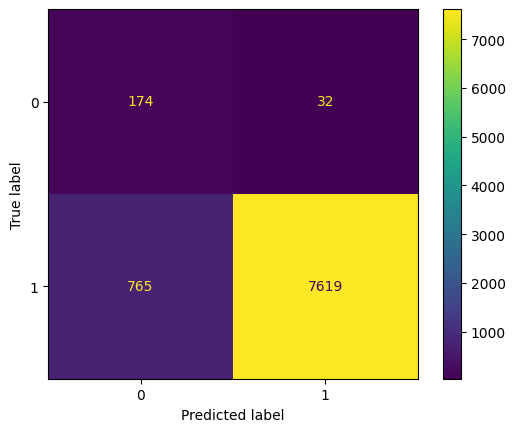

In [11]:
ConfusionMatrixDisplay(
    confusion_matrix(
        cv_truths_perma,
        clf_preds_perma,
    )
).plot()

print(
    classification_report(
        cv_truths_perma,
        clf_preds_perma,
    )
)